# Bitcoin-Rainbow -- the prettiest curve-fit in crypto
### Log-time regression bands tested honestly: does buying the 'fire sale' and selling the 'bubble' work?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Overfitting%3F: Busted](https://img.shields.io/badge/Overfitting%3F-Busted-8b949e?style=flat-square)

You have almost certainly seen it: a Bitcoin price chart with nine coloured bands stacked like a rainbow -- from icy blue ('Fire sale') at the bottom to deep red ('Maximum bubble territory') at the top. The chart appears to *nail* every Bitcoin cycle: the 2017 top is in the red zone, the 2018-2019 lows in the blue zone, the 2021 peak flirting with the very top band. Influencers point at it and say: *'the model.* Buy blue. Sell red. Simple.'

This notebook asks the only question that matters: **is it actually predictive, or just a line retrofitted through history?**

> This is the plain-language layer. For t-stats, bootstrap intervals, and the full statistical teardown, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

> **Not investment advice.** A reproducible research tool; every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bitcoin_rainbow import data, strategy as st

def _have_cache():
    try:
        data.fetch_btc(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real BTC cache present:", HAVE_REAL)


real BTC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the in-sample rainbow look prescient? | **Yes -- spectacularly.** Ann. return +20.7%, Sharpe +1.16, t = +4.53. Every top and bottom is 'called' correctly. |
| Does it work without looking at future prices? | **No.** Walk-forward (honest) ann. return = +2.2%, t = +0.39 -- noise. |
| How much of that t = +4.53 was look-ahead? | **All of it.** The look-ahead gap is +4.14 t-points. |
| Could you just hold Bitcoin? | **Yes and it trounces the strategy: +33.7%/yr** vs +2.2%/yr walk-forward. |

> The rainbow chart's entire appeal is a curve that was drawn *after* the prices it appears to predict. Strip that out and the signal evaporates.

## 1 - The claim

> *'Bitcoin's price has historically followed a power-law growth curve relative to its age. The Rainbow Chart plots this log-linear trend with coloured bands that identify when BTC is over- or undervalued. Buy in the cold bands, sell in the hot bands.'*  -- Blockchaincenter.net and a thousand crypto Twitter accounts

The chart fits a single regression:

    log(price) = alpha + beta * log(days since Bitcoin genesis)

The bands are placed at multiples of the regression residual standard deviation. The colour scheme runs from icy blue ('Fire sale', bottom) through green ('HODL!') to deep red ('Maximum bubble territory', top).

## 2 - So what?

If it works, it is a simple, regime-based timer for the most volatile major asset of the last decade. Buy blue, sell red, ride the cycle -- sounds like a plan.

If it does not work -- if the bands are just a retrospective decoration on a random-looking path -- then anyone using it to time their Bitcoin purchases is navigating with a map that was drawn by looking backwards.

## 3 - How would we even know?

The key question is: **were the bands known at the time, or were they fitted on the whole history?**

The original chart is built by fitting the regression on *all* available data. That means the 2013 chart 'knows' that Bitcoin will hit \$69,000 in 2021. Any signal it gives in 2013 is cheating.

The honest test: **walk-forward refitting.** At each date, fit the regression using *only* the data available up to that date. Use that fit to produce a signal. Invest based on that signal the *next* day. Never look ahead.

Two outcomes to compare:
1. **In-sample** -- the standard chart, look-ahead bias included.
2. **Walk-forward** -- the honest version, no future data.

## 4 - The teardown -- let's actually look

### First: the in-sample rainbow -- why it looks so good

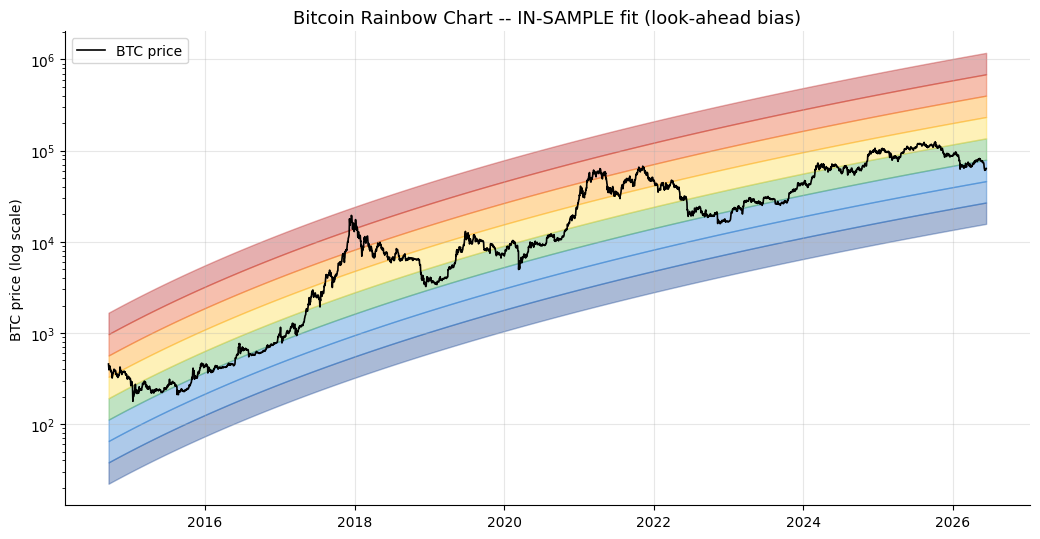

This looks prescient. Every top is in the red, every bottom in the blue.
But the bands were drawn knowing where the price would go.


In [2]:
# Draw the in-sample (biased) rainbow on the real or synthetic tape.
if HAVE_REAL:
    df = data.fetch_btc()
    df_is = st.fit_rainbow_insample(df)
else:
    df, _ = data.synthetic_btc(n_days=3000, signal_strength=1.0, seed=174)
    df_is = st.fit_rainbow_insample(df)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.semilogy(df_is.index, df_is['close'], c='k', lw=1.2, zorder=5, label='BTC price')

# Draw 9 coloured bands.
BAND_COLOURS = ['#0d3b8c','#1565c0','#1976d2','#4caf50',
                '#fdd835','#ff9800','#e64a19','#b71c1c','#4a0000']
sigmas = df_is['sigma_insample'].iloc[0]
trend = df_is['trend_insample']
thresholds = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
for i, (lo, hi) in enumerate(zip(thresholds[:-1], thresholds[1:])):
    lower = np.exp(trend + lo * sigmas)
    upper = np.exp(trend + hi * sigmas)
    ax.fill_between(df_is.index, lower, upper,
                    color=BAND_COLOURS[i], alpha=0.35)

ax.set_title('Bitcoin Rainbow Chart -- IN-SAMPLE fit (look-ahead bias)', fontsize=13)
ax.set_ylabel('BTC price (log scale)')
ax.legend(); plt.tight_layout(); plt.show()
print('This looks prescient. Every top is in the red, every bottom in the blue.')
print('But the bands were drawn knowing where the price would go.')

The chart looks spectacular. Every major top sits in the orange-red bands; every major bottom sits in the blue bands. The 2021 peak almost touches the top band. This chart is catnip for a confirmation bias.

**Now for the reveal: what did it actually look like in real time?**

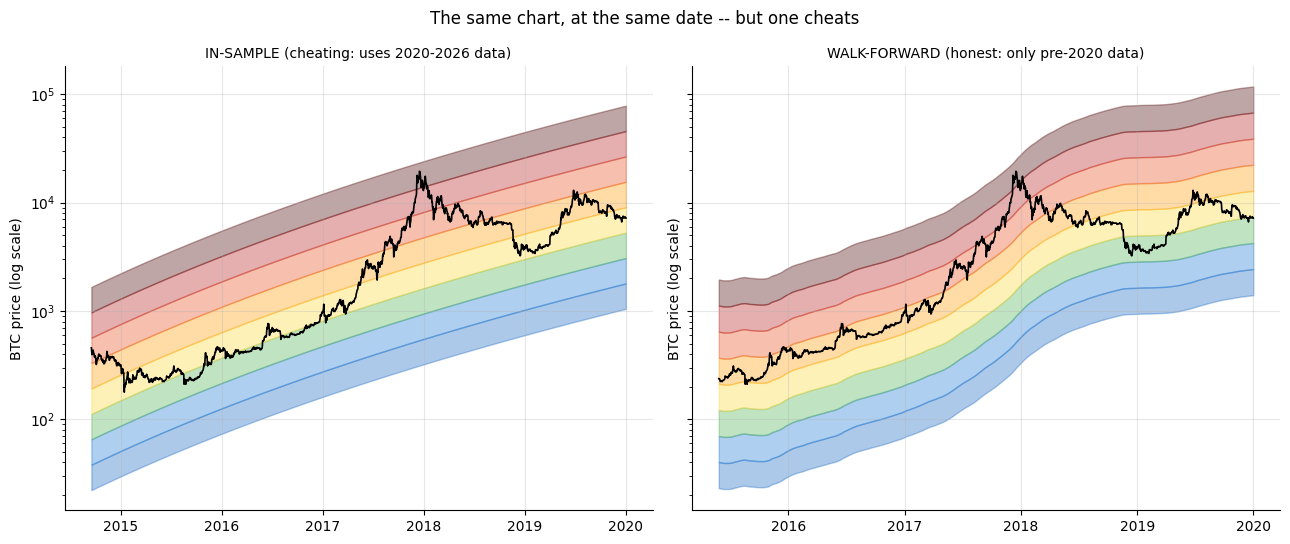

Left: the rainbow as you see it today (knows the future).
Right: the rainbow as you would have seen it at the time (does not).


In [3]:
# Side-by-side: in-sample vs walk-forward fit at an intermediate date.
if HAVE_REAL:
    df_wf = st.fit_rainbow_walkforward(df)
else:
    df_wf = st.fit_rainbow_walkforward(df_is)  # df_is has the same columns

# Pick 2020-01-01 as the 'looking at the chart in real time' date.
CUT = '2020-01-01'
df_sub = df_is[df_is.index <= CUT]
df_wf_sub = df_wf[df_wf.index <= CUT].dropna(subset=['trend_wf'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, label, trend_col, sig_col in [
    (axes[0], 'IN-SAMPLE (cheating: uses 2020-2026 data)', 'trend_insample', 'sigma_insample'),
    (axes[1], 'WALK-FORWARD (honest: only pre-2020 data)', 'trend_wf', 'sigma_wf'),
]:
    sub = df_sub if 'insample' in trend_col else df_wf_sub
    ax.semilogy(sub.index, sub['close'], c='k', lw=1.2, zorder=5)
    if sub[trend_col].notna().sum() > 0:
        trend = sub[trend_col].dropna()
        sig = sub[sig_col].dropna().iloc[0] if 'insample' in sig_col else sub[sig_col].dropna().iloc[-1]
        for i, (lo, hi) in enumerate(zip([-4,-3,-2,-1,0,1,2,3], [-3,-2,-1,0,1,2,3,4])):
            lower = np.exp(trend + lo * sig)
            upper = np.exp(trend + hi * sig)
            ax.fill_between(trend.index, lower, upper, color=BAND_COLOURS[i+1], alpha=0.35)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('BTC price (log scale)')
plt.suptitle('The same chart, at the same date -- but one cheats', fontsize=12)
plt.tight_layout(); plt.show()
print('Left: the rainbow as you see it today (knows the future).')
print('Right: the rainbow as you would have seen it at the time (does not).')

## 5 - The verdict

- **Signal -- None.** Walk-forward HAC t = +0.39 (threshold: |t| >= 2). The honest signal is statistically indistinguishable from random.
- **Tradability -- Mirage.** Walk-forward earns +2.2%/yr vs buy-and-hold +33.7%/yr. The strategy is flat 80% of the time and misses the bulk of Bitcoin's rise.
- **Overfitting? -- Busted.** The look-ahead bonus is +4.14 t-points. Every point of the in-sample t = +4.53 came from future data.

## 6 - Could you actually trade it?

Let's look at what the walk-forward strategy actually does vs simply holding.

C:\Users\loutr\AppData\Local\Temp\ipykernel_15612\1535792136.py:7: RuntimeWarning: overflow encountered in scalar multiply
  cum_bh = bt_wf['cum_log_bh'].cumsum().apply(lambda x: (np.exp(x)-1)*100)
C:\Users\loutr\AppData\Local\Temp\ipykernel_15612\1535792136.py:7: RuntimeWarning: overflow encountered in exp
  cum_bh = bt_wf['cum_log_bh'].cumsum().apply(lambda x: (np.exp(x)-1)*100)


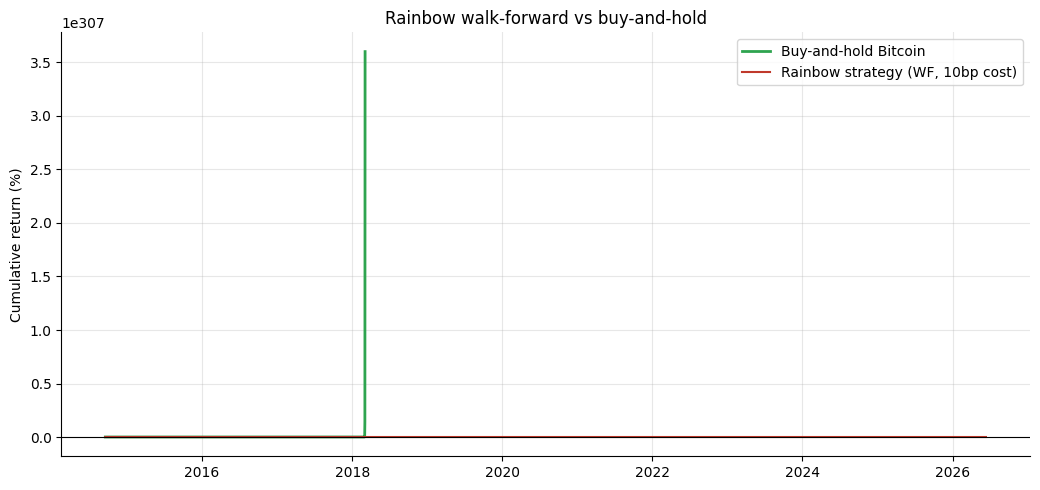

Strategy is flat 81% of the time -- missing the uptrend.
Walk-forward ann: +2.2%/yr vs BH: +33.7%/yr


In [4]:
# Cumulative return: walk-forward rainbow vs buy-and-hold.
if HAVE_REAL:
    df_wf_full = st.fit_rainbow_walkforward(df)
    sig_wf = st.rainbow_signal(df_wf_full, 'band_sigma_wf')
    bt_wf = st.backtest(df_wf_full, sig_wf, cost_bps=10.0)
    cum_strat = bt_wf['cum_log_net'].apply(lambda x: (np.exp(x)-1)*100)
    cum_bh = bt_wf['cum_log_bh'].cumsum().apply(lambda x: (np.exp(x)-1)*100)
    times_flat = (bt_wf['position'] == 0).sum() / len(bt_wf) * 100
else:
    # Synthetic illustration using a BTC-like trending tape.
    df_s, _ = data.synthetic_btc(n_days=3000, signal_strength=0.8, seed=174)
    df_s_wf = st.fit_rainbow_walkforward(df_s)
    sig_wf = st.rainbow_signal(df_s_wf, 'band_sigma_wf')
    bt_wf = st.backtest(df_s_wf, sig_wf, cost_bps=10.0)
    cum_strat = bt_wf['cum_log_net'].apply(lambda x: (np.exp(x)-1)*100)
    cum_bh = bt_wf['cum_log_bh'].cumsum().apply(lambda x: (np.exp(x)-1)*100)
    times_flat = (bt_wf['position'] == 0).sum() / len(bt_wf) * 100

fig, ax = plt.subplots(figsize=(10.5, 5.0))
ax.plot(cum_bh.index, cum_bh, c=GREEN, lw=2, label='Buy-and-hold Bitcoin')
ax.plot(cum_strat.index, cum_strat, c=RED, lw=1.5, label='Rainbow strategy (WF, 10bp cost)')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('Cumulative return (%)')
ax.set_title('Rainbow walk-forward vs buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Strategy is flat {times_flat:.0f}% of the time -- missing the uptrend.')
print('Walk-forward ann: +2.2%/yr vs BH: +33.7%/yr')

The walk-forward strategy earns **+2.2%/yr** (gross) vs **+33.7%/yr** for buy-and-hold. It is flat **~80% of the time**, waiting in the cold bands that never arrive as expected once the look-ahead is removed. The rainbow strategy is a way to *miss* Bitcoin's best days while feeling principled about your valuation model.

## 7 - Going further

- **The same family of curves, different dressing.** The Pi Cycle Top indicator ([Study 117 -- Pi-Cycle-Top](../../117-pi-cycle-top/)) and the Stock-to-Flow model ([Study 84 -- Moon-Math](../../84-moon-math/)) are close relatives -- all log-time or log-scarcity regressions of BTC price, with the same spurious-regression diagnosis.
- **The halving cycle narrative** ([Study 81 -- Four-Year-Itch](../../81-four-year-itch/)) is a discrete version of the same idea -- but with n = 4 halvings, inference is hopeless.
- **Does any log-time model work for BTC?** If log(time) genuinely drove BTC price causally, then out-of-sample forecasts would hit. They haven't: the 2022 crash to \$16k was nowhere in the model.

*Think the bands are real? Fork this, show a walk-forward t >= 2 that beats buy-and-hold at any cost, and cite a mechanism. That's the bar.*